# Diabetes Prediction from Medical Data

Predicting the likelihood of diabetes using the Pima Indians Diabetes dataset. 
Approach: clean the data, explore it, then train and compare Logistic Regression 
and Random Forest classifiers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
   df = pd.read_csv('diabetes.csv')

   df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 768
Number of columns: 9


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
print(df.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [7]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [8]:
zero_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

for col in zero_columns:
    print(col, ":", (df[col] == 0).sum())

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


In [9]:
df[zero_columns] = df[zero_columns].replace(0, np.nan)

In [10]:
for col in zero_columns:
    df[col] = df[col].fillna(df[col].median())

In [11]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [13]:
df = df.drop_duplicates()

print("Dataset shape:", df.shape)

Dataset shape: (768, 9)


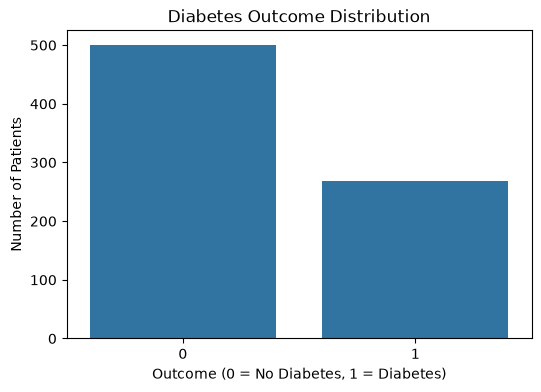

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x='Outcome', data=df)

plt.title('Diabetes Outcome Distribution')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Number of Patients')

plt.show()

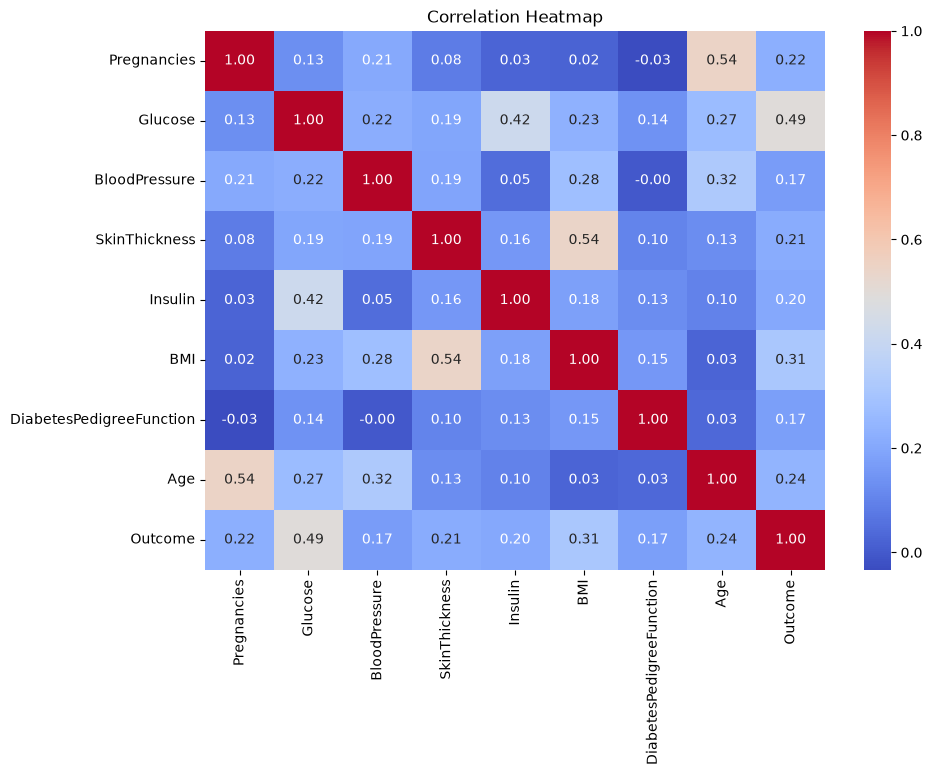

In [15]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

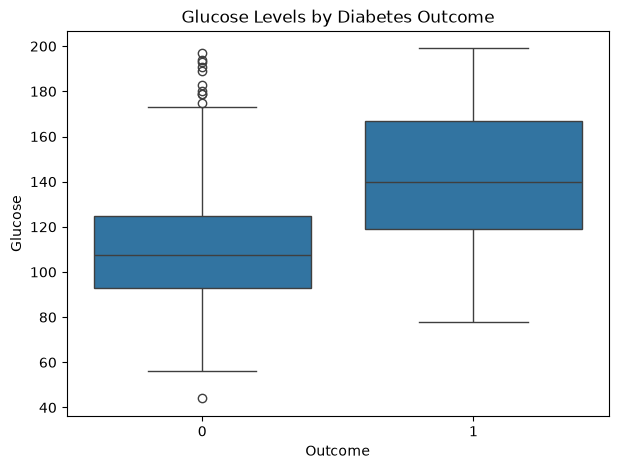

In [16]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Outcome',
    y='Glucose',
    data=df
)

plt.title('Glucose Levels by Diabetes Outcome')
plt.xlabel('Outcome')
plt.ylabel('Glucose')

plt.show()

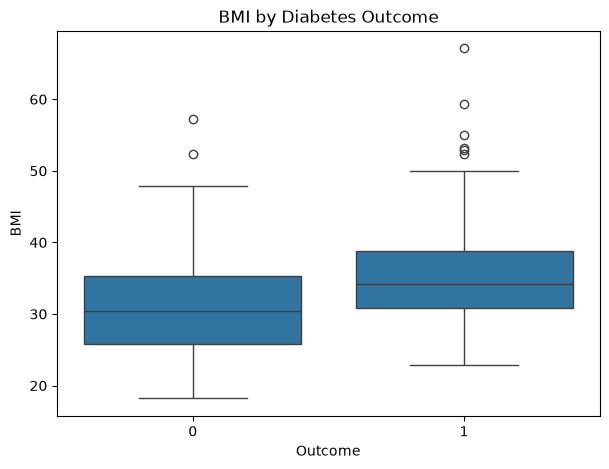

In [17]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Outcome',
    y='BMI',
    data=df
)

plt.title('BMI by Diabetes Outcome')
plt.xlabel('Outcome')
plt.ylabel('BMI')

plt.show()

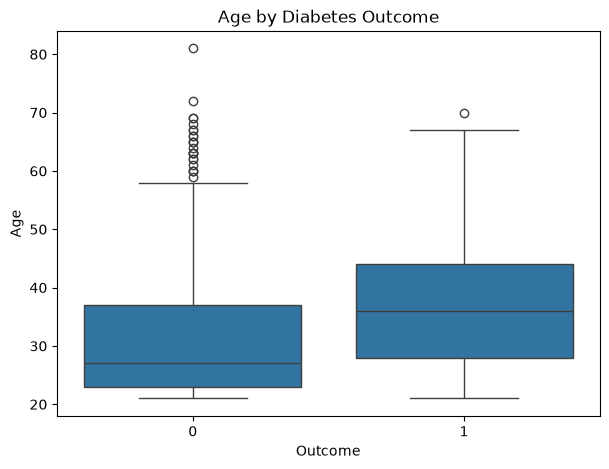

In [18]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Outcome',
    y='Age',
    data=df
)

plt.title('Age by Diabetes Outcome')
plt.xlabel('Outcome')
plt.ylabel('Age')

plt.show()

## Model Preparation
Splitting data into train/test sets and scaling features for Logistic Regression.

In [19]:
X = df.drop('Outcome', axis=1)

y = df['Outcome']

In [20]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target:
Outcome


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 614
Testing samples: 154


In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [23]:
logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [24]:
y_pred_lr = logistic_model.predict(X_test_scaled)

print(y_pred_lr[:20])

[1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0]


In [25]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression Results
---------------------------
Accuracy : 0.7077922077922078
Precision: 0.6
Recall   : 0.5
F1 Score : 0.5454545454545454


In [26]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



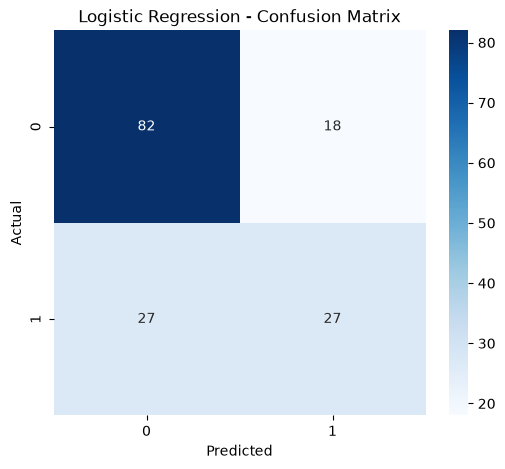

In [27]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [28]:
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

lr_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression ROC-AUC:", lr_auc)

Logistic Regression ROC-AUC: 0.812962962962963


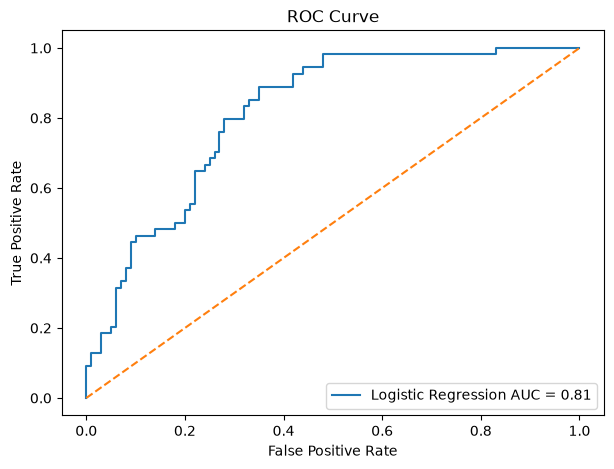

In [29]:
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression AUC = {lr_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()

plt.show()

## Random Forest Model
Using `class_weight='balanced'` to improve recall on the diabetic class, since 
missing a true diabetic case is costlier than a false alarm in a screening context.

In [30]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [31]:
y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf[:20])

[1 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 1 0 1 0]


In [32]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest Results
---------------------
Accuracy : 0.7597402597402597
Precision: 0.6491228070175439
Recall   : 0.6851851851851852
F1 Score : 0.6666666666666666


In [33]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81       100
           1       0.65      0.69      0.67        54

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



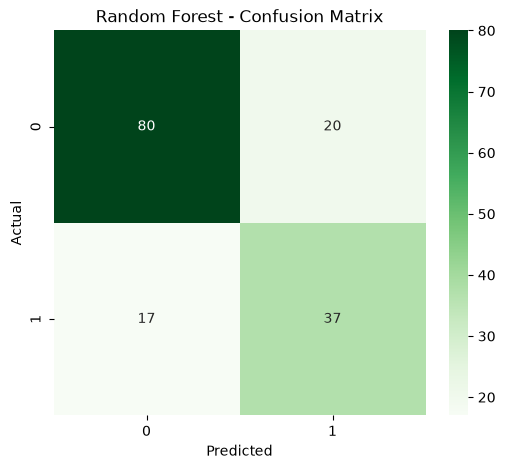

In [34]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [35]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
1,Glucose,0.265777
5,BMI,0.160784
7,Age,0.124010
6,DiabetesPedigreeFunction,0.119306
4,Insulin,0.099784
2,BloodPressure,0.079071
3,SkinThickness,0.077093
0,Pregnancies,0.074176


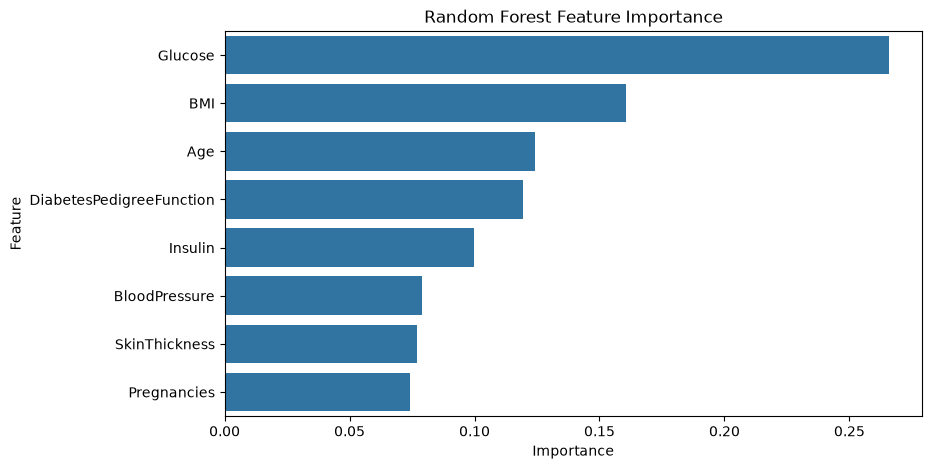

In [36]:
plt.figure(figsize=(9,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Random Forest Feature Importance')

plt.show()

In [37]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    
    'Accuracy': [
        lr_accuracy,
        rf_accuracy
    ],
    
    'Precision': [
        lr_precision,
        rf_precision
    ],
    
    'Recall': [
        lr_recall,
        rf_recall
    ],
    
    'F1 Score': [
        lr_f1,
        rf_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455
1,Random Forest,0.759740,0.649123,0.685185,0.666667


In [38]:
best_model = results.loc[
    results['F1 Score'].idxmax()
]

print("Best Model:", best_model['Model'])
print("F1 Score:", best_model['F1 Score'])

Best Model: Random Forest
F1 Score: 0.6666666666666666


In [39]:
def predict_diabetes(
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    bmi,
    diabetes_pedigree,
    age
):
    
    patient = pd.DataFrame([[
        pregnancies,
        glucose,
        blood_pressure,
        skin_thickness,
        insulin,
        bmi,
        diabetes_pedigree,
        age
    ]], columns=X.columns)
    
    prediction = rf_model.predict(patient)[0]
    
    probability = rf_model.predict_proba(patient)[:, 1][0]
    
    result = "Higher predicted likelihood of diabetes" if prediction == 1 else "Lower predicted likelihood of diabetes"
    
    return result, probability

In [40]:
result, probability = predict_diabetes(
    2,
    120,
    70,
    20,
    79,
    25.5,
    0.30,
    25
)

print("Prediction:", result)
print("Probability:", round(probability * 100, 2), "%")

Prediction: Lower predicted likelihood of diabetes
Probability: 3.0 %


## Conclusion
Random Forest outperforms Logistic Regression on F1 score and recall. 
Glucose, BMI, and Age are the strongest predictors of diabetes risk.